In [1]:
# Installation des versions stables pour ton PFE
!pip install scikeras scikit-learn==1.5.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 34.6 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.9.post2 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.41 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


Chargement des données...
Création d'un échantillon de 15000 lignes pour l'optimisation...

--- DÉBUT DU GRID SEARCH (Deep Learning Corrigé) ---
Fitting 3 folds for each of 8 candidates, totalling 24 fits
-> Meilleur R² DL: 0.4853 (en 226.5s)
-> Meilleurs Params: {'model__learning_rate': 0.001, 'model__n_layers': 3, 'model__n_neurons': 128}

Génération des graphiques de performance...


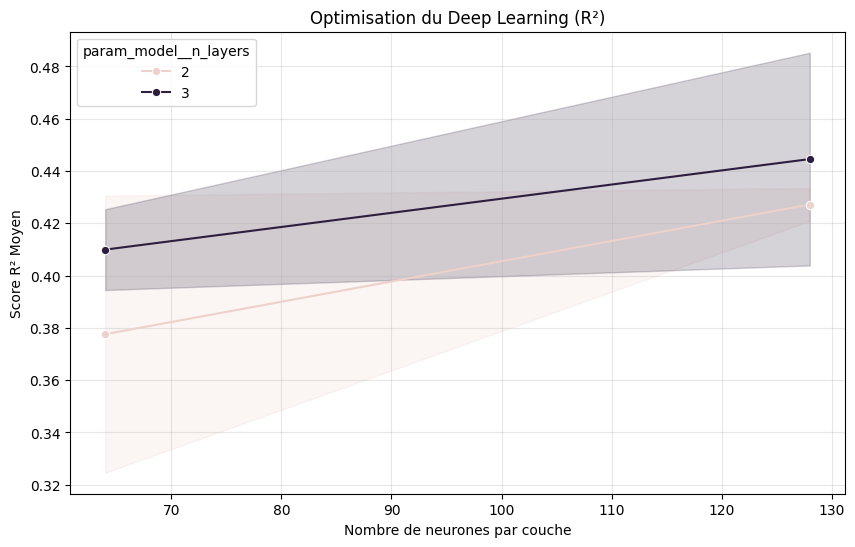

🏆 MEILLEURE ARCHITECTURE DL : {'model__learning_rate': 0.001, 'model__n_layers': 3, 'model__n_neurons': 128}

Lancement de l'entraînement FINAL sur 359201 lignes...
Epoch 1/50
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 786.4714
Epoch 2/50
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 74.1340
Epoch 3/50
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 66.4403
Epoch 4/50
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 63.0733
Epoch 5/50
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 61.6918
Epoch 6/50
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 59.0843
Epoch 7/50
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 57.5442
Epoch 8/50
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 55.1576
Epoch 9/50
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 54.4827
Epoch 10/50
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 52.4037
Epoch 11/50
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 51.7013
Epoch 12/50
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss:

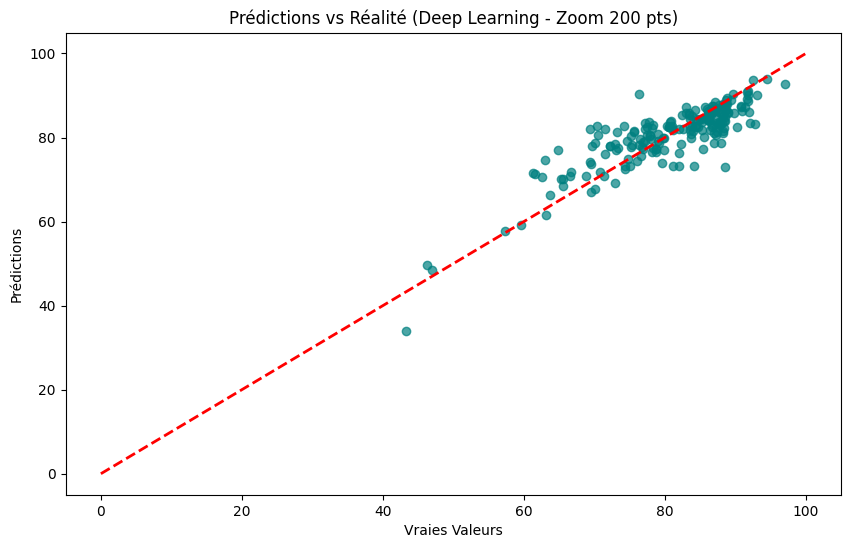


Sauvegarde du modèle DL et du scaler...
✅ Sauvegarde terminée : 'best_model_dl_tuned.pkl' et 'scaler_dl_tuned.pkl'


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time

# TensorFlow & SciKeras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from scikeras.wrappers import KerasRegressor

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# =================================================================
# 0. CORRECTIF DE COMPATIBILITÉ (POUR ÉVITER L'ERREUR TAGS)
# =================================================================
class CompatibleKerasRegressor(KerasRegressor):
    """Version corrigée du wrapper pour Scikit-Learn 1.6+"""
    def __sklearn_tags__(self):
        from sklearn.utils._estimator_tags import EstimatorTags
        tags = EstimatorTags()
        tags.regressor_tags.predict_2d = True
        return tags

# =================================================================
# 1. CHARGEMENT ET PRÉPARATION
# =================================================================
print("Chargement des données...")
# Assure-toi que le fichier est bien présent dans ton répertoire Colab
df = pd.read_csv('data_ready_to_use.csv')

target_col = "LIT_002_FILTER_WATER_STG_TNK"

try:
    target_index = df.columns.get_loc(target_col)
    X = df.iloc[:, :target_index]
    y = df[target_col]
except KeyError:
    print(f"Erreur : Cible '{target_col}' introuvable.")
    exit()

# Scaling (Vital pour la convergence du réseau de neurones)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =================================================================
# 2. ÉCHANTILLONNAGE POUR GRID SEARCH
# =================================================================
SAMPLE_SIZE = 15000
print(f"Création d'un échantillon de {SAMPLE_SIZE} lignes pour l'optimisation...")
indices_sample = np.random.choice(X.shape[0], SAMPLE_SIZE, replace=False)
X_sample = X_scaled[indices_sample]
y_sample = y.iloc[indices_sample]

# =================================================================
# 3. DÉFINITION DU MODÈLE ET DE LA GRILLE
# =================================================================
def create_dl_model(n_layers=2, n_neurons=64, learning_rate=0.001):
    model = Sequential()
    model.add(Input(shape=(X.shape[1],)))
    for _ in range(n_layers):
        model.add(Dense(n_neurons, activation='relu'))
        model.add(Dropout(0.1))
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
    return model

# Utilisation de la classe corrigée 'CompatibleKerasRegressor'
dl_model = CompatibleKerasRegressor(
    model=create_dl_model,
    epochs=20,
    batch_size=128,
    verbose=0,
    n_layers=2,
    n_neurons=64,
    learning_rate=0.001
)

param_grid = {
    'model__n_layers': [2, 3],
    'model__n_neurons': [64, 128],
    'model__learning_rate': [0.01, 0.001]
}

# =================================================================
# 4. EXÉCUTION DU GRID SEARCH
# =================================================================
print("\n--- DÉBUT DU GRID SEARCH (Deep Learning Corrigé) ---")
start = time.time()

# n_jobs=1 est préférable avec TensorFlow pour éviter les conflits mémoire/GPU
grid_dl = GridSearchCV(dl_model, param_grid, cv=3, scoring='r2', n_jobs=1, verbose=1)
grid_dl.fit(X_sample, y_sample)

end = time.time()
print(f"-> Meilleur R² DL: {grid_dl.best_score_:.4f} (en {end-start:.1f}s)")
print(f"-> Meilleurs Params: {grid_dl.best_params_}")

# =================================================================
# 5. VISUALISATION DES RÉSULTATS
# =================================================================
print("\nGénération des graphiques de performance...")
dl_res = pd.DataFrame(grid_dl.cv_results_)

plt.figure(figsize=(10, 6))
sns.lineplot(data=dl_res, x='param_model__n_neurons', y='mean_test_score', hue='param_model__n_layers', marker='o')
plt.title("Optimisation du Deep Learning (R²)")
plt.xlabel("Nombre de neurones par couche")
plt.ylabel("Score R² Moyen")
plt.grid(True, alpha=0.3)
plt.show()

# =================================================================
# 6. ENTRAÎNEMENT FINAL (SUR TOUT LE DATASET)
# =================================================================
print("="*60)
print(f"🏆 MEILLEURE ARCHITECTURE DL : {grid_dl.best_params_}")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"\nLancement de l'entraînement FINAL sur {len(X_train)} lignes...")
final_dl = CompatibleKerasRegressor(
    model=create_dl_model,
    **grid_dl.best_params_,
    epochs=50,
    batch_size=256,
    verbose=1 # Affiche la progression de TensorFlow
)

start_final = time.time()
final_dl.fit(X_train, y_train)
print(f"Entraînement terminé en {time.time() - start_final:.2f} secondes.")

# =================================================================
# 7. SCORING ET SAUVEGARDE
# =================================================================
print("\nÉvaluation finale sur le jeu de test...")
y_pred = final_dl.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"--- RÉSULTATS FINAUX (Deep Learning) ---")
print(f"R² Score : {r2:.4f}")
print(f"MAE      : {mae:.4f}")
print(f"RMSE     : {rmse:.4f}")

# Visualisation Prédiction vs Réalité
plt.figure(figsize=(10, 6))
plt.scatter(y_test[:200], y_pred[:200], alpha=0.7, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Vraies Valeurs")
plt.ylabel("Prédictions")
plt.title(f"Prédictions vs Réalité (Deep Learning - Zoom 200 pts)")
plt.show()

print("\nSauvegarde du modèle DL et du scaler...")
joblib.dump(final_dl, 'best_model_dl_tuned.pkl')
joblib.dump(scaler, 'scaler_dl_tuned.pkl')
print("✅ Sauvegarde terminée : 'best_model_dl_tuned.pkl' et 'scaler_dl_tuned.pkl'")

In [5]:
import pandas as pd
import numpy as np
import joblib
from scikeras.wrappers import KerasRegressor

# =================================================================
# 0. REDÉFINITION DU CORRECTIF (OBLIGATOIRE POUR LE CHARGEMENT)
# =================================================================
class CompatibleKerasRegressor(KerasRegressor):
    def __sklearn_tags__(self):
        from sklearn.utils._estimator_tags import EstimatorTags
        tags = EstimatorTags()
        tags.regressor_tags.predict_2d = True
        return tags

# =================================================================
# 1. CHARGEMENT DES COMPOSANTS
# =================================================================
print("Chargement du modèle et du scaler...")
try:
    # On charge le modèle et le scaler sauvegardés
    model_dl = joblib.load('best_model_dl_tuned.pkl')
    scaler_dl = joblib.load('scaler_dl_tuned.pkl')
    print("✅ Composants chargés avec succès.")
except Exception as e:
    print(f"❌ Erreur de chargement : {e}")

# =================================================================
# 2. EXTRACTION DE LA DONNÉE RÉELLE (Ligne 1)
# =================================================================
# On utilise le même fichier pour garantir la structure des colonnes
df = pd.read_csv('data_ready_to_use.csv')
target_col = "LIT_002_FILTER_WATER_STG_TNK"

# On suit EXACTEMENT la logique d'entraînement pour extraire X
target_index = df.columns.get_loc(target_col)

# On prend la première ligne complète
premiere_ligne_all = df.iloc[[0]]

# On extrait X (toutes les colonnes AVANT la cible, comme à l'entraînement)
X_brut = premiere_ligne_all.iloc[:, :target_index]
y_reel = premiere_ligne_all[target_col].values[0]

# =================================================================
# 3. PIPELINE DE PRÉDICTION
# =================================================================

# Étape 1 : Normalisation (Scaling)
# Le scaler connaît déjà le nom et l'ordre des colonnes du fit()
X_scaled = scaler_dl.transform(X_brut)

# Étape 2 : Prédiction via le Réseau de Neurones
prediction = model_dl.predict(X_scaled)

# =================================================================
# 4. AFFICHAGE DES RÉSULTATS
# =================================================================
print("\n" + "="*50)
print("VÉRIFICATION : MODÈLE CHARGÉ VS RÉALITÉ")
print("="*50)
print(f"VALEUR RÉELLE (Ligne 1) : {y_reel:.4f}")
print(f"PRÉDICTION DL          : {prediction[0]:.4f}")
print("-" * 50)
erreur = abs(y_reel - prediction[0])
print(f"ERREUR ABSOLUE         : {erreur:.4f}")
print(f"PRÉCISION              : {(1 - (erreur/y_reel))*100:.2f} %")
print("="*50)

Chargement du modèle et du scaler...
✅ Composants chargés avec succès.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step

VÉRIFICATION : MODÈLE CHARGÉ VS RÉALITÉ
VALEUR RÉELLE (Ligne 1) : 82.8938
PRÉDICTION DL          : 84.0973
--------------------------------------------------
ERREUR ABSOLUE         : 1.2035
PRÉCISION              : 98.55 %
